In [1]:
##########################################################################
#                       1. SETUP & INGESTION                             #
##########################################################################

# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Statistical tests
from scipy import stats
import pingouin as pg

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Preprocessing (will be used later)
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Download the dataset from Kaggle
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

# Load the CSV file
df = pd.read_csv(path + "/train.csv", low_memory=False)

# Display dataset dimensions
print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTotal data points: {df.shape[0] * df.shape[1]:,}")

# Show first few rows
df.head()

Dataset Dimensions: 100000 rows × 28 columns

Total data points: 2,800,000


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
# Display data types
print("Data Types Overview:")
print("=" * 50)
df.dtypes

Data Types Overview:


ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

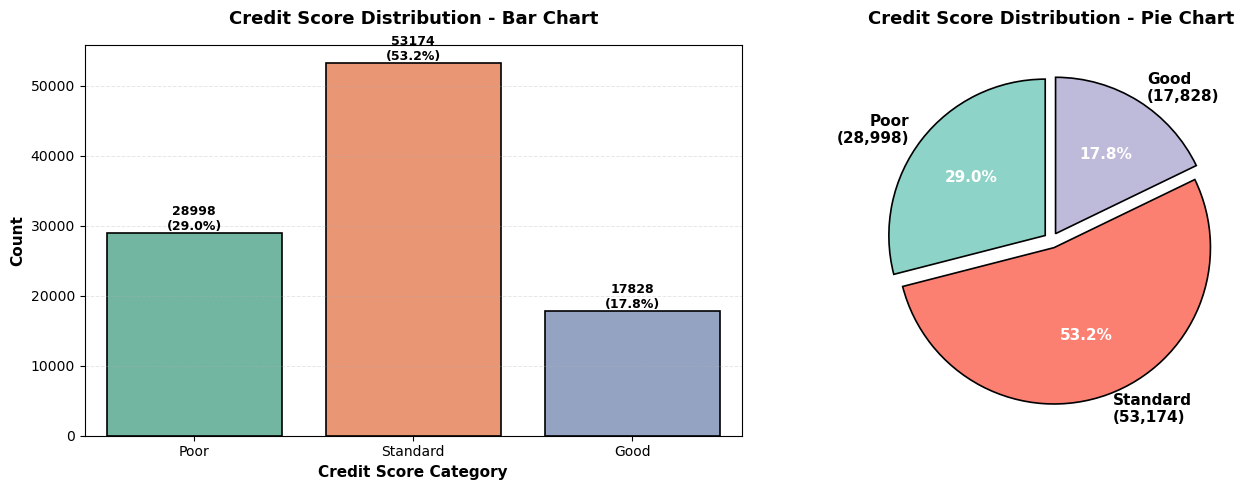


Target Variable - Normalized Distribution:
Credit_Score
Good        0.17828
Poor        0.28998
Standard    0.53174
Name: proportion, dtype: float64


In [4]:
##########################################################################
#                  2. PRELIMINARY EDA (DIRTY DATA)                       #
##########################################################################

# Visualize TARGET DISTRIBUTION using Bar + Pie Chart (styled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Get value counts in the correct order
credit_order = ['Poor', 'Standard', 'Good']
credit_counts = df['Credit_Score'].value_counts()[credit_order]
total = len(df['Credit_Score'])

# Left plot: Bar chart
sns.countplot(data=df, x='Credit_Score', ax=ax1, palette='Set2', 
              edgecolor='black', linewidth=1.2, order=credit_order)

ax1.set_title('Credit Score Distribution - Bar Chart', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Credit Score Category', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.tick_params(axis='both', labelsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

# Add combined count and percentage labels on bars
for patch in ax1.patches:
    height = patch.get_height()
    percentage = (height / total) * 100
    ax1.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(height)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Right plot: Pie chart
colors = ['#8dd3c7', '#fb8072', '#bebada']  # Set2 palette colors
explode = (0.05, 0.05, 0.05)  # Slightly separate slices

wedges, texts, autotexts = ax2.pie(credit_counts, labels=credit_order, autopct='%1.1f%%',
                                     colors=colors, explode=explode, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'},
                                     wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})

# Enhance autopct text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Add count to labels
for i, (label, count) in enumerate(zip(texts, credit_counts)):
    label.set_fontsize(11)
    label.set_fontweight('bold')
    label.set_text(f'{label.get_text()}\n({count:,})')

ax2.set_title('Credit Score Distribution - Pie Chart', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\nTarget Variable - Normalized Distribution:")
print(df['Credit_Score'].value_counts(normalize=True).sort_index())

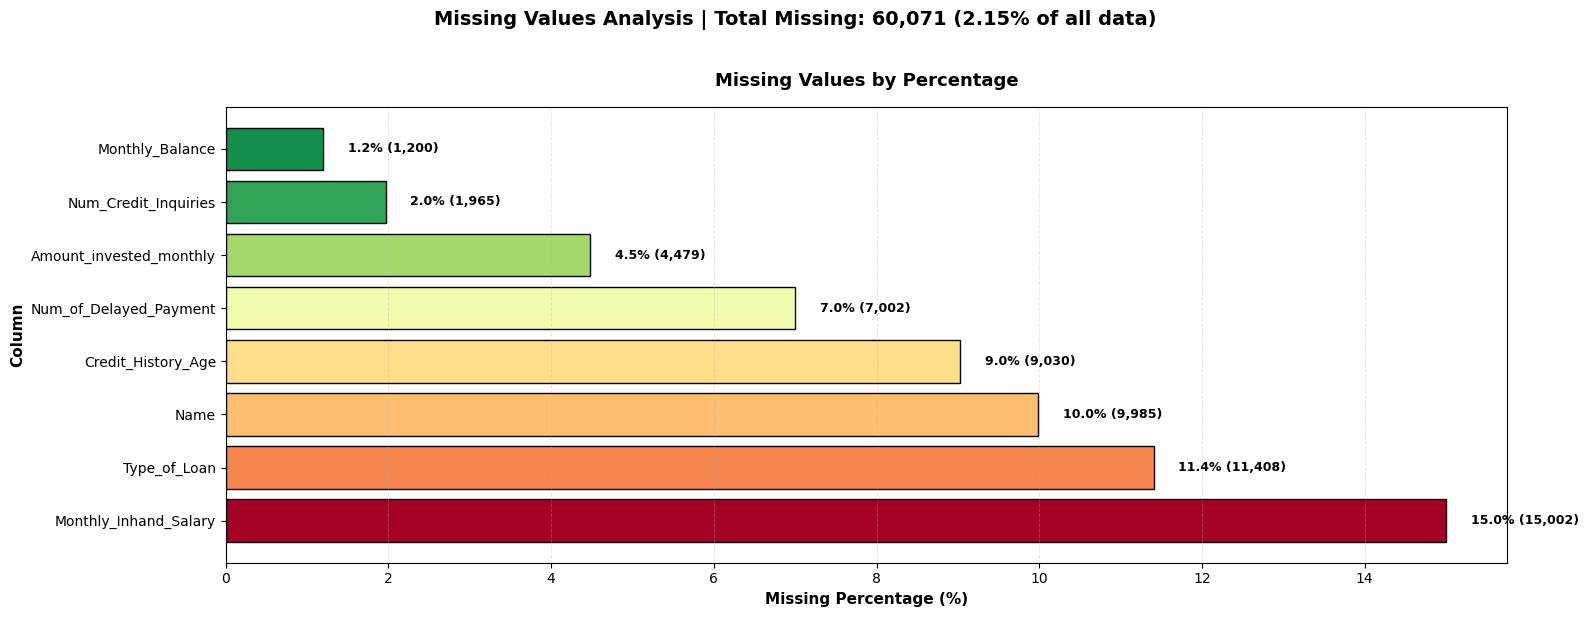


Missing Values Summary:
Total missing values: 60,071
Percentage of total data: 2.15%
Columns with missing values: 8 out of 28


In [5]:
# Visualize MISSING VALUES (styled horizontal bar with gradient)

fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Filter columns with missing values
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)

# Horizontal bar chart with gradient colors
colors_gradient = plt.cm.RdYlGn_r(missing_df['Percentage'] / missing_df['Percentage'].max())
bars = ax1.barh(missing_df['Column'], missing_df['Percentage'], color=colors_gradient, 
                edgecolor='black', linewidth=1)

ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
ax1.set_title('Missing Values by Percentage', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

# Add percentage labels on bars
for i, (bar, pct, count) in enumerate(zip(bars, missing_df['Percentage'], missing_df['Count'])):
    width = bar.get_width()
    ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}% ({int(count):,})',
             ha='left', va='center', fontsize=9, fontweight='bold')

# Add summary statistics
total_missing = missing_count.sum()
total_cells = df.shape[0] * df.shape[1]
overall_pct = (total_missing / total_cells) * 100

fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Display summary
print("\nMissing Values Summary:")
print(f"Total missing values: {int(total_missing):,}")
print(f"Percentage of total data: {overall_pct:.2f}%")
print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}")

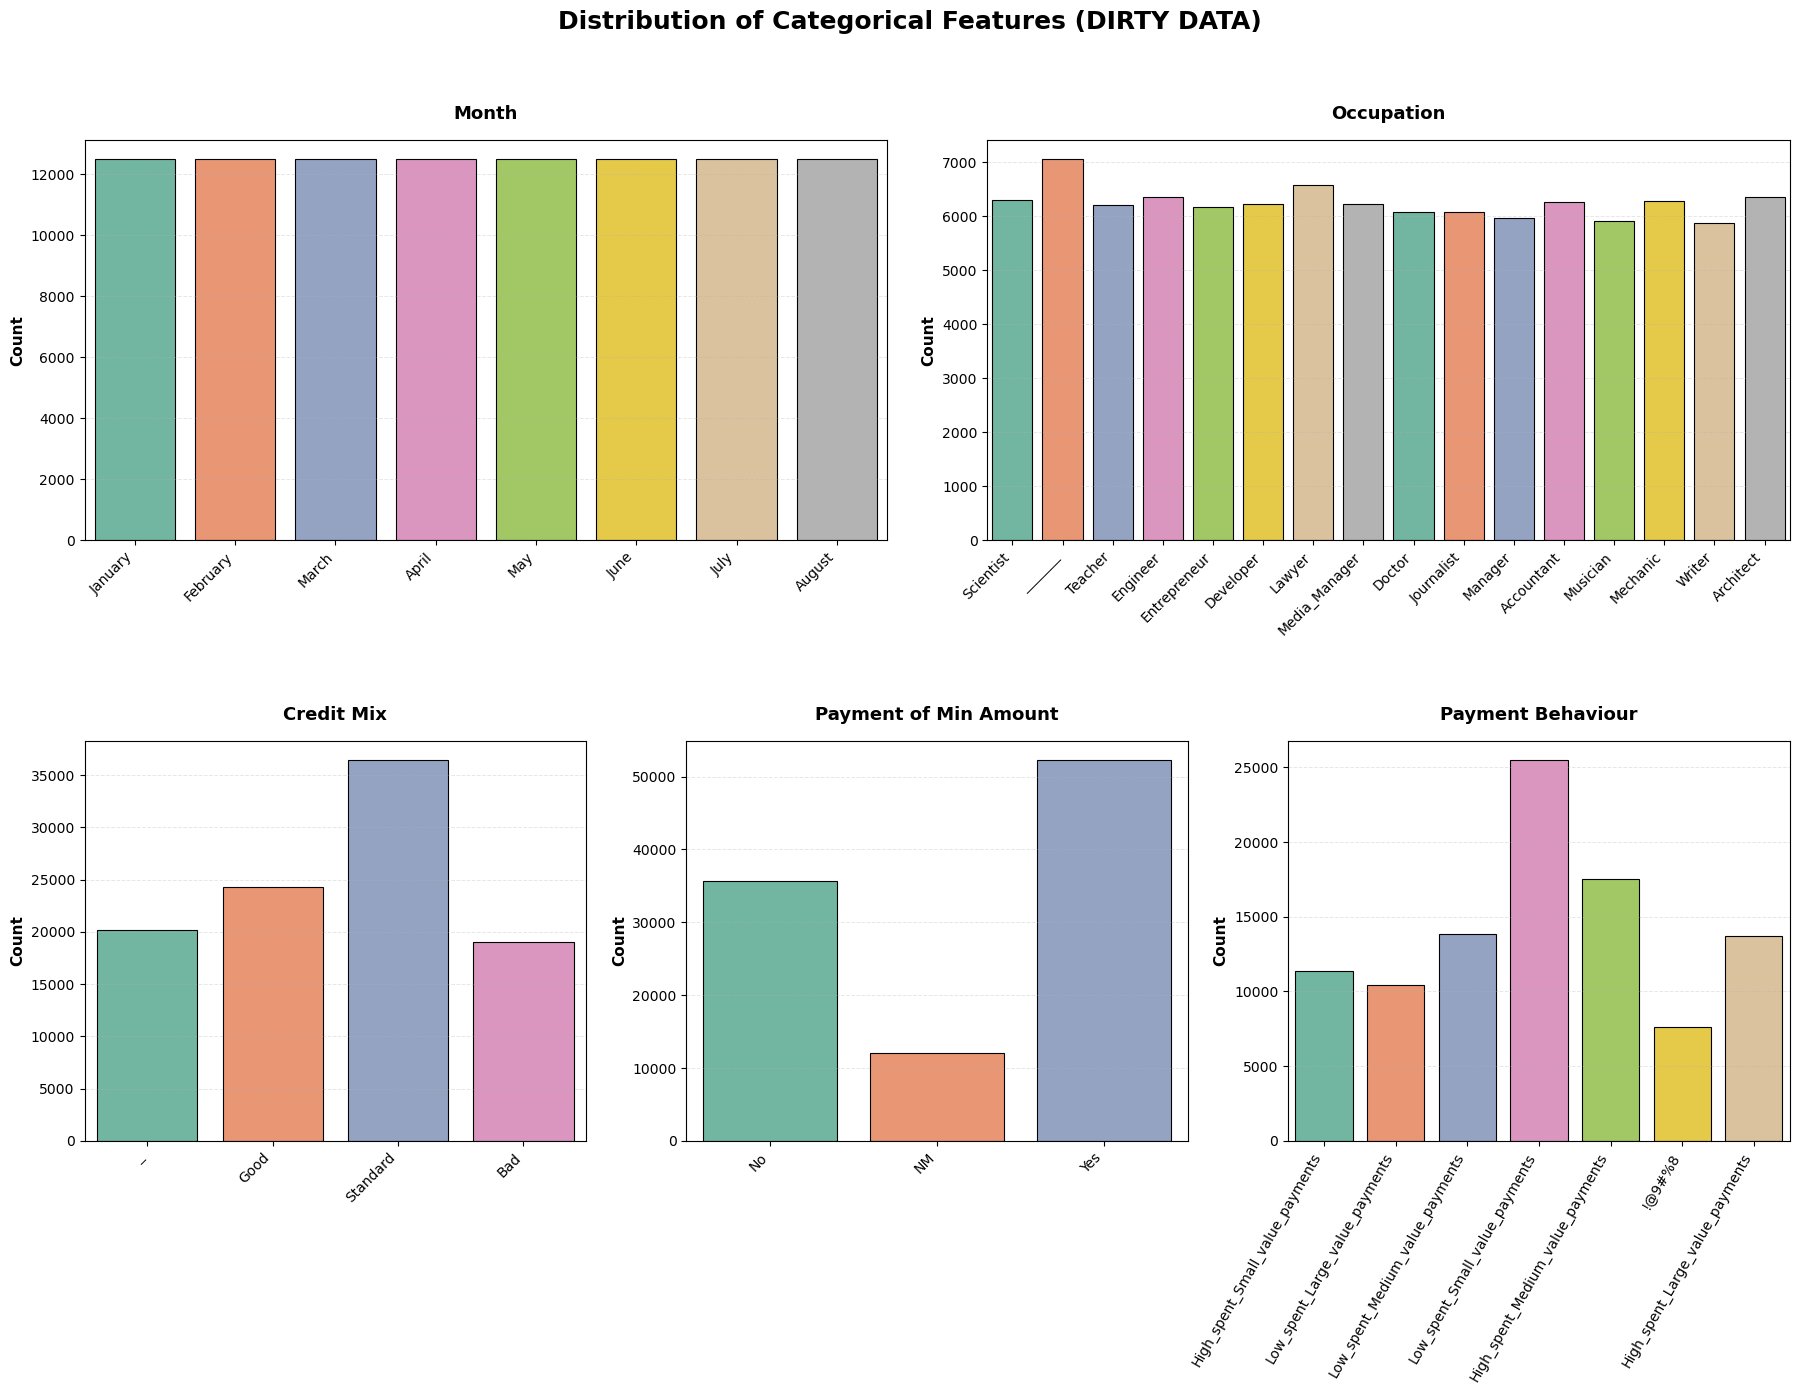


⚠️  Issues visible in categorical features:
   - Occupation: Contains '_______' placeholder
   - Credit_Mix: Contains '_' placeholder
   - Payment_Behaviour: Contains '!@9#%8' invalid value
   - Payment_of_Min_Amount: Contains 'NM' (needs standardization)


In [6]:
# Visualize DIRTY CATEGORICAL features (GridSpec layout)

columns = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

fig = plt.figure(figsize=(22, 13))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.5, wspace=0.5)

# Row 1: 2 plots centered
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Row 2: 3 plots
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes_list = [ax1, ax2, ax3, ax4, ax5]

fig.suptitle('Distribution of Categorical Features (DIRTY DATA)', fontsize=18, fontweight='bold', y=0.98)

for idx, col in enumerate(columns):
    ax = axes_list[idx]
    sns.countplot(data=df, x=col, ax=ax, palette='Set2', edgecolor='black', linewidth=0.8)
    ax.set_title(f'{col.replace("_", " ")}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=11, fontweight='bold')
    
    # Special handling for Payment_Behaviour with long labels
    if col == 'Payment_Behaviour':
        ax.tick_params(axis='x', rotation=60, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
            label.set_fontweight('medium')
    else:
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')
    
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("\n⚠️  Issues visible in categorical features:")
print("   - Occupation: Contains '_______' placeholder")
print("   - Credit_Mix: Contains '_' placeholder")
print("   - Payment_Behaviour: Contains '!@9#%8' invalid value")
print("   - Payment_of_Min_Amount: Contains 'NM' (needs standardization)")

In [7]:
# Quick look at problematic numerical columns stored as objects

print("Sample values from columns that should be numeric:")
print("\nAge samples:", df['Age'].head(10).tolist())
print("Annual_Income samples:", df['Annual_Income'].head(10).tolist())
print("Outstanding_Debt samples:", df['Outstanding_Debt'].head(10).tolist())
print("\n⚠️  Underscores present in numeric data - needs cleaning!")

Sample values from columns that should be numeric:

Age samples: ['23', '23', '-500', '23', '23', '23', '23', '23', '28_', '28']
Annual_Income samples: ['19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '34847.84', '34847.84']
Outstanding_Debt samples: ['809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '605.03', '605.03']

⚠️  Underscores present in numeric data - needs cleaning!


In [8]:
##########################################################################
#                3. PHASE 1 CLEANING (STRUCTURAL)                        #
##########################################################################

# Step 1: Drop useless identifier columns
print("Step 1: Dropping ID, Name, SSN (not useful for prediction)")
cols_to_drop = ['ID', 'Name', 'SSN']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"   ✓ Dropped {len(cols_to_drop)} columns. New shape: {df.shape}")

# Step 2: Fix numeric columns stored as strings (remove underscores)
print("\nStep 2: Converting object columns to numeric (removing underscores)")
cols_to_fix = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in cols_to_fix:
    df[col] = df[col].str.replace('_', '')
    try:
        df[col] = df[col].astype('float')
        print(f"   ✓ {col} converted to float")
    except:
        print(f"   ⚠ {col} conversion failed (will handle separately)")
        continue

# Special handling for Changed_Credit_Limit (has empty strings)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].replace('', np.nan)
df['Changed_Credit_Limit'] = df['Changed_Credit_Limit'].astype('float')
print(f"   ✓ Changed_Credit_Limit: empty strings replaced with NaN")

print(f"\nConverted columns info:")
df[cols_to_fix].info()

Step 1: Dropping ID, Name, SSN (not useful for prediction)
   ✓ Dropped 3 columns. New shape: (100000, 25)

Step 2: Converting object columns to numeric (removing underscores)
   ✓ Age converted to float
   ✓ Annual_Income converted to float
   ✓ Num_of_Loan converted to float
   ✓ Num_of_Delayed_Payment converted to float
   ⚠ Changed_Credit_Limit conversion failed (will handle separately)
   ✓ Outstanding_Debt converted to float
   ✓ Amount_invested_monthly converted to float
   ✓ Monthly_Balance converted to float
   ✓ Changed_Credit_Limit: empty strings replaced with NaN

Converted columns info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  float64
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  float64
 3   Num_

In [9]:
# Step 3: Handle negative values (convert to NaN)
print("Step 3: Replacing negative values with NaN (illogical values)")
columns_to_fix = ['Age', 'Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit']

df[columns_to_fix] = df[columns_to_fix].applymap(lambda x: np.nan if x < 0 else x)

print("   Negative values summary (before cleaning):")
for col in columns_to_fix:
    neg_count = (df[col].isna().sum())
    print(f"   - {col}: {neg_count} values set to NaN")

print("\n   ✓ Negative values replaced with NaN")

Step 3: Replacing negative values with NaN (illogical values)
   Negative values summary (before cleaning):
   - Age: 886 values set to NaN
   - Num_Bank_Accounts: 21 values set to NaN
   - Num_of_Loan: 3876 values set to NaN
   - Num_of_Delayed_Payment: 7646 values set to NaN
   - Changed_Credit_Limit: 3677 values set to NaN

   ✓ Negative values replaced with NaN


In [10]:
# Step 4: Fix categorical placeholders and special values
print("Step 4: Cleaning categorical features")

# Replace invalid placeholders with NaN
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
print("   ✓ Occupation: '_______' → NaN")

df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
print("   ✓ Credit_Mix: '_' → NaN")

df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)
print("   ✓ Payment_Behaviour: '!@9#%8' → NaN")

df['Payment_of_Min_Amount'].replace('NM', 'No', inplace=True)
print("   ✓ Payment_of_Min_Amount: 'NM' → 'No'")

print("\nCategorical cleaning complete!")

Step 4: Cleaning categorical features
   ✓ Occupation: '_______' → NaN
   ✓ Credit_Mix: '_' → NaN
   ✓ Payment_Behaviour: '!@9#%8' → NaN
   ✓ Payment_of_Min_Amount: 'NM' → 'No'

Categorical cleaning complete!


In [11]:
# Step 5: Feature engineering - Credit_History_Age to months
print("Step 5: Converting Credit_History_Age from 'X Years Y Months' to total months")

def to_months(val):
    if pd.isnull(val):
        return val
    x = int(val.split(' ')[0])  # Years
    y = int(val.split(' ')[3])  # Months
    return x * 12 + y

df['Credit_History_Age'] = df['Credit_History_Age'].apply(lambda x: to_months(x)).astype(float)
print(f"   ✓ Credit_History_Age converted to months")
print(f"   Range: {df['Credit_History_Age'].min():.0f} to {df['Credit_History_Age'].max():.0f} months")

Step 5: Converting Credit_History_Age from 'X Years Y Months' to total months
   ✓ Credit_History_Age converted to months
   Range: 1 to 404 months


In [12]:
# Step 6: Convert Customer_ID from hexadecimal string to integer
print("Step 6: Converting Customer_ID from hex string to integer")

print(f"   Before: {df['Customer_ID'].head(3).tolist()}")
df['Customer_ID'] = df['Customer_ID'].apply(lambda x: int(x[4:], 16))
print(f"   After:  {df['Customer_ID'].head(3).tolist()}")
print(f"   ✓ Customer_ID converted to integer")

print("\n" + "="*70)
print("PHASE 1 CLEANING COMPLETE - Data structure fixed!")
print("="*70)

Step 6: Converting Customer_ID from hex string to integer
   Before: ['CUS_0xd40', 'CUS_0xd40', 'CUS_0xd40']
   After:  [3392, 3392, 3392]
   ✓ Customer_ID converted to integer

PHASE 1 CLEANING COMPLETE - Data structure fixed!


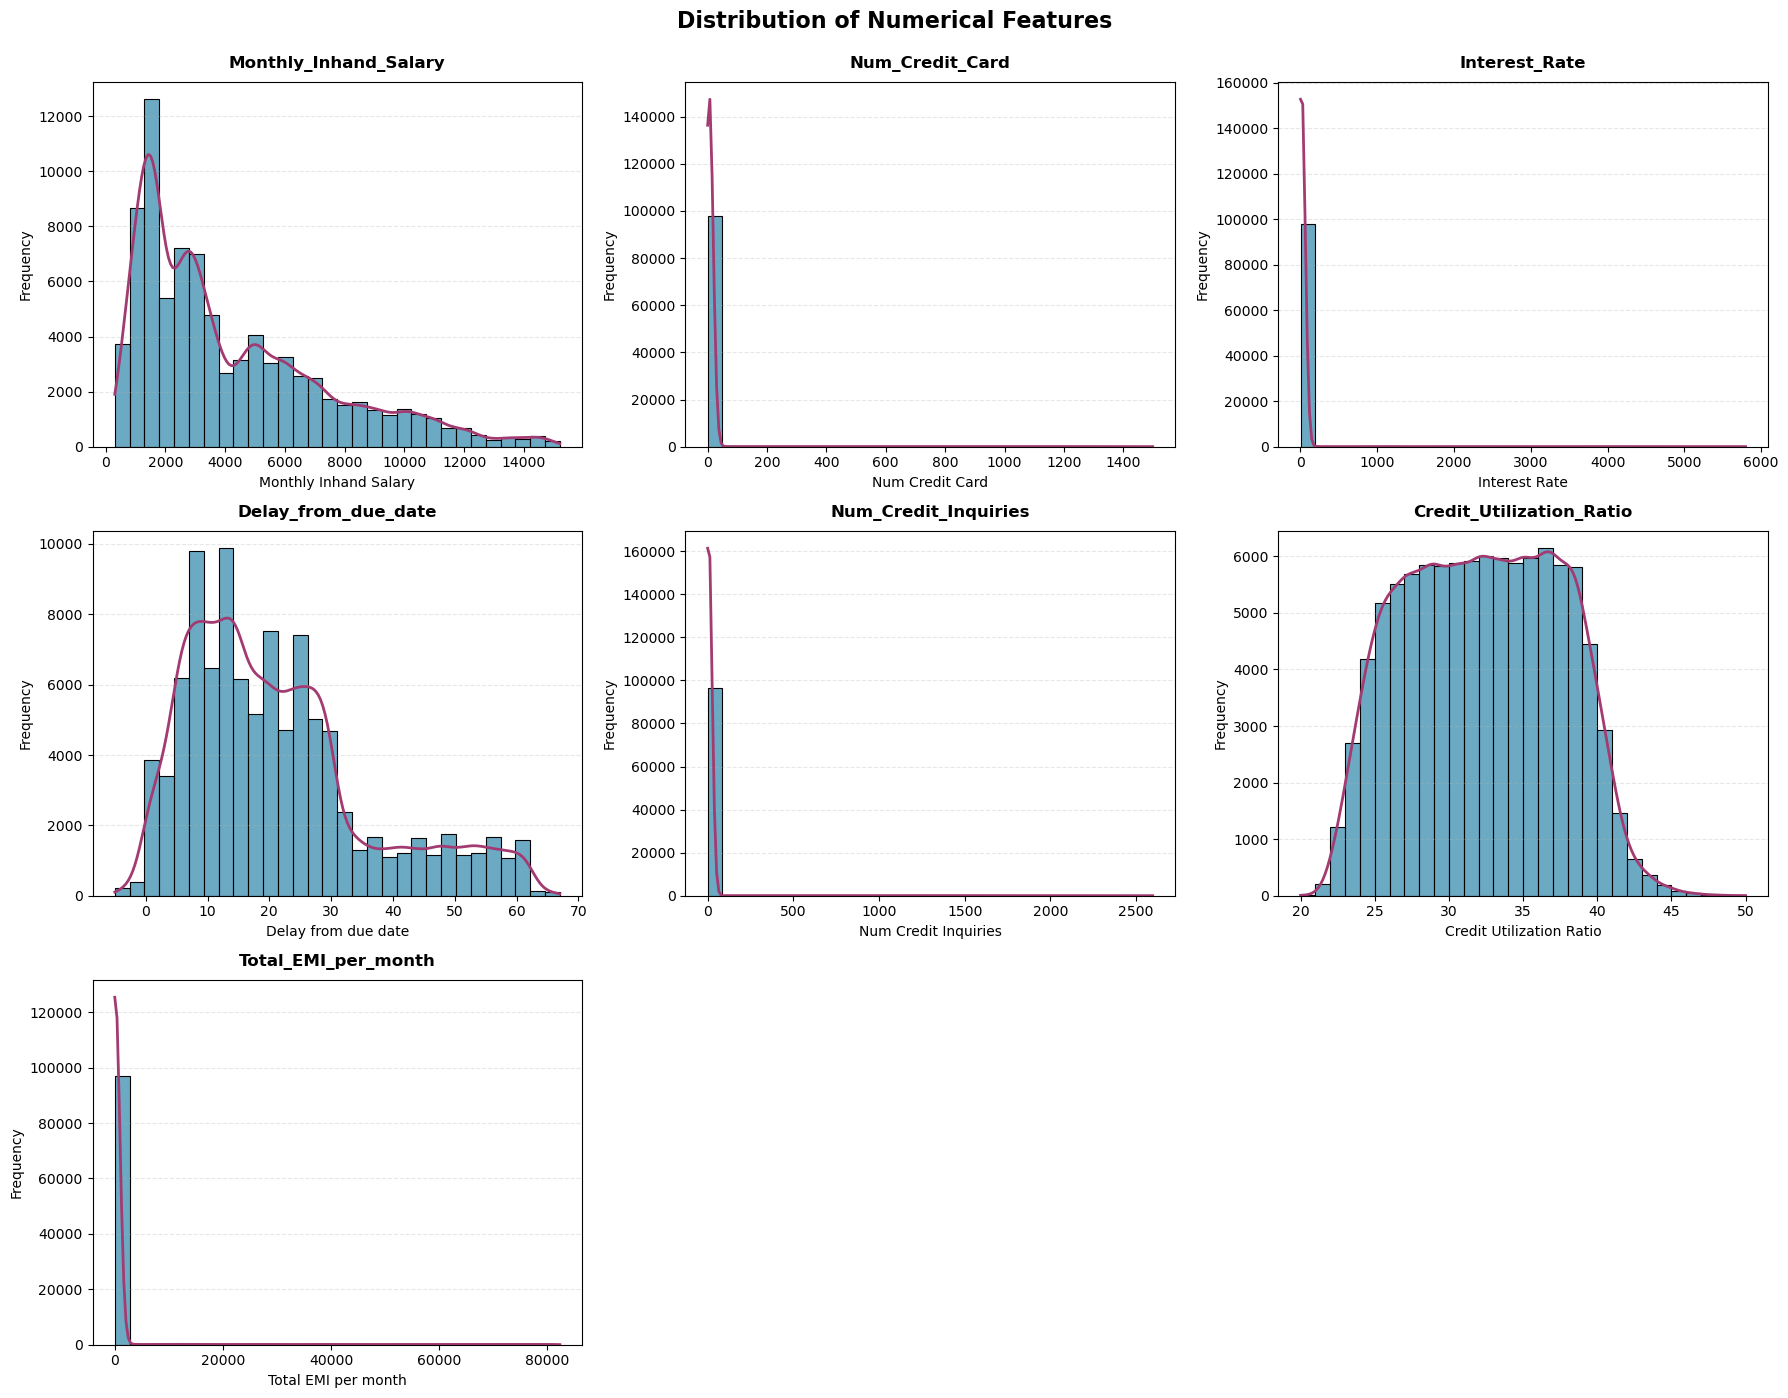

In [13]:
##########################################################################
#                   4. DEEP EDA (CLEAN DATA)                             #
##########################################################################

# Now that data types are fixed, we can perform proper numerical analysis

# Visualize NUMERICAL FEATURES with Histograms + KDE

columns = ['Monthly_Inhand_Salary', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
           'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, col in enumerate(columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#2E86AB', 
                 edgecolor='black', linewidth=0.8, bins=30, alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel(col.replace('_', ' '), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Style KDE line
    for line in axes[idx].lines:
        line.set_color('#A23B72')
        line.set_linewidth(2)

# Hide extra subplots
for idx in range(len(columns), 9):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

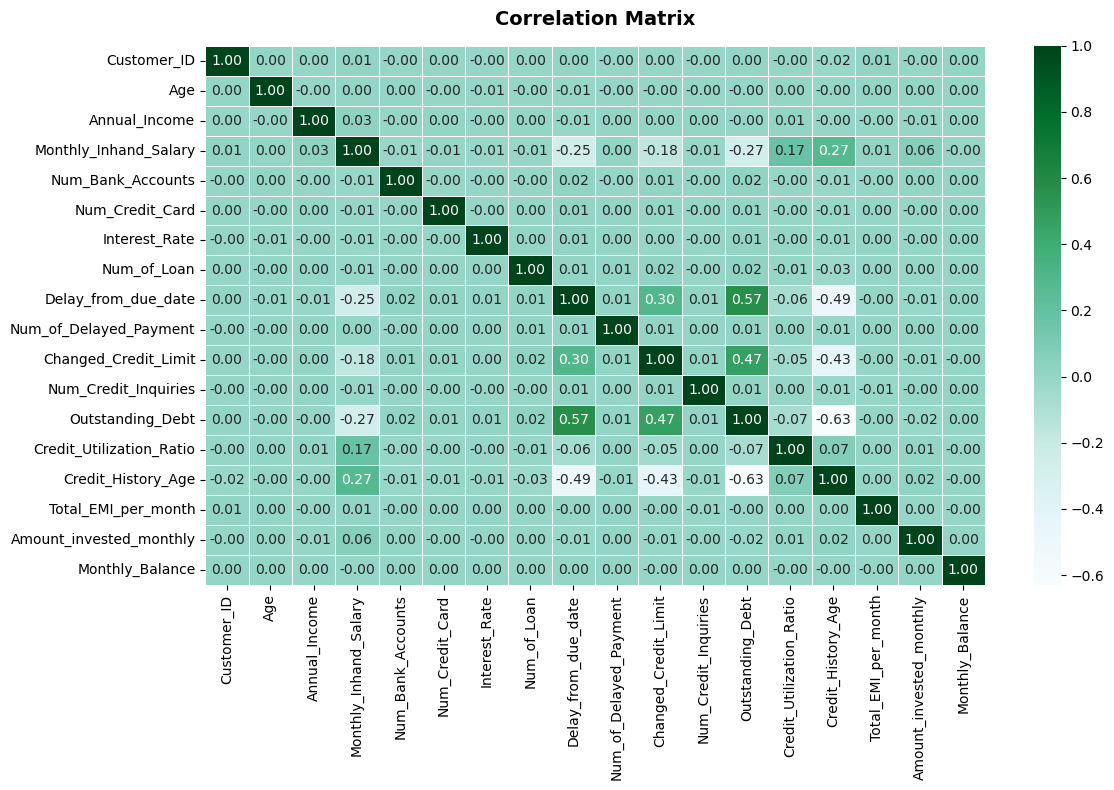


Top 5 positive correlations with features:
(Excluding self-correlations)


In [14]:
# Correlation Matrix Heatmap

corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='BuGn', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\nTop 5 positive correlations with features:")
print("(Excluding self-correlations)")

In [15]:
# Encode Credit_Score temporarily for visualizations (will do properly later)
credit_score_temp = df['Credit_Score'].copy()
label_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['Credit_Score_Encoded'] = df['Credit_Score'].map(label_map)

# Select key numerical columns for deep analysis
num_cols = df.select_dtypes(include=['int64', 'float64']).columns[1:-1].tolist()

print(f"Total numerical columns for analysis: {len(num_cols)}")
print(f"Columns: {num_cols[:10]}...")  # Show first 10

Total numerical columns for analysis: 17
Columns: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit']...


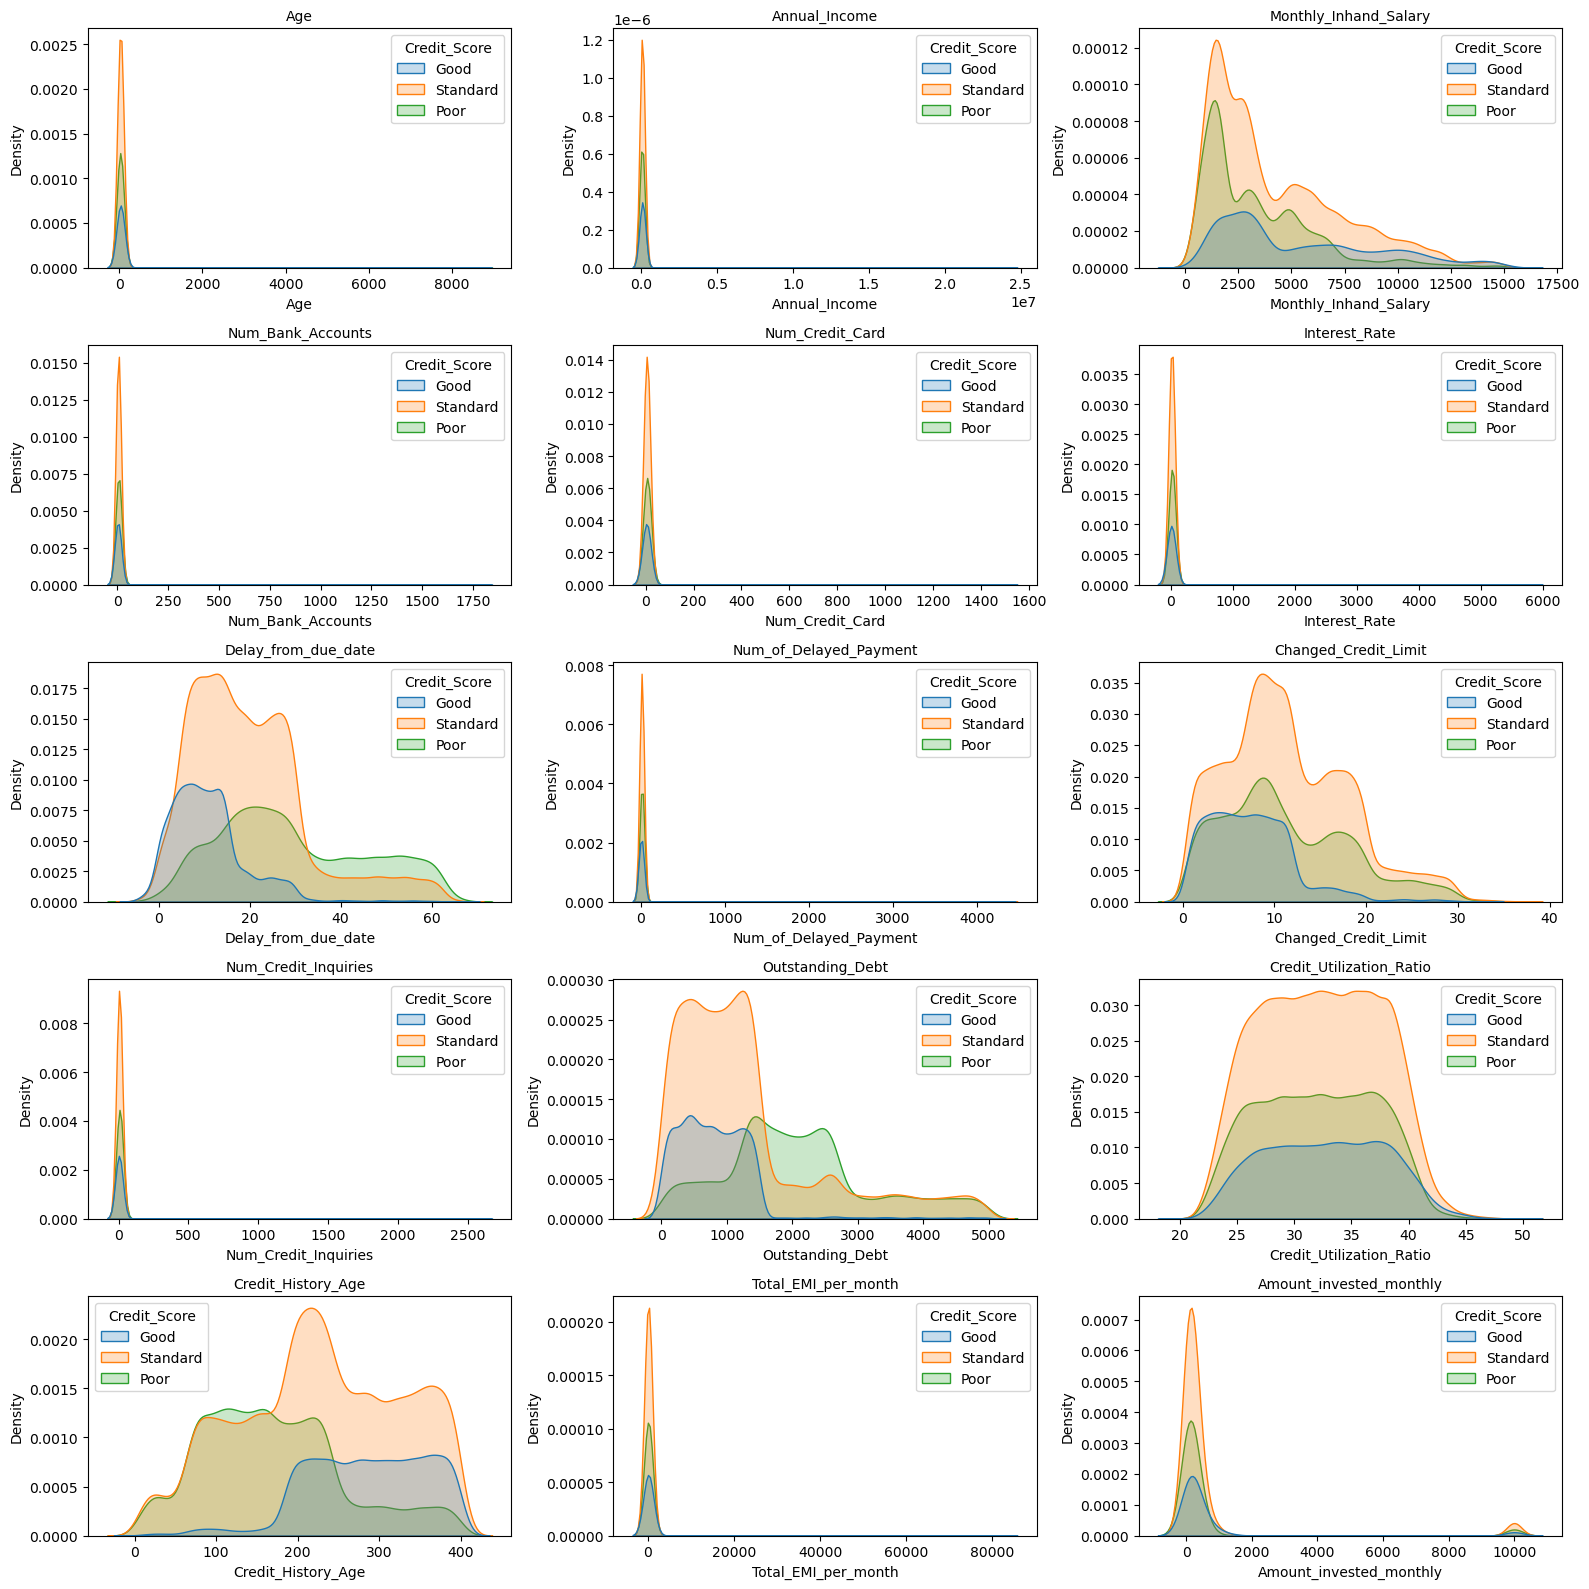


✓ KDE plots show distribution of features across Credit Score categories


In [16]:
# KDE Distributions by Credit Score class (sample of features)

# Select 15 most important numerical features for KDE visualization
kde_features = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
    'Total_EMI_per_month', 'Amount_invested_monthly'
]

plt.figure(figsize=(16, 16))

for ax, col in enumerate(kde_features):
    plt.subplot(5, 3, ax + 1)
    plt.title(col, fontsize=10)
    sns.kdeplot(x=df[col], shade=True, hue=df['Credit_Score'])

plt.tight_layout()
plt.show()

print("\n✓ KDE plots show distribution of features across Credit Score categories")

Creating Pairplot for key features...
Features selected:
  1. Outstanding_Debt
  2. Credit_History_Age
  3. Delay_from_due_date
  4. Num_of_Delayed_Payment
  5. Annual_Income
  6. Total_EMI_per_month

Using sample of 10,000 rows for pairplot (original: 100,000 rows)


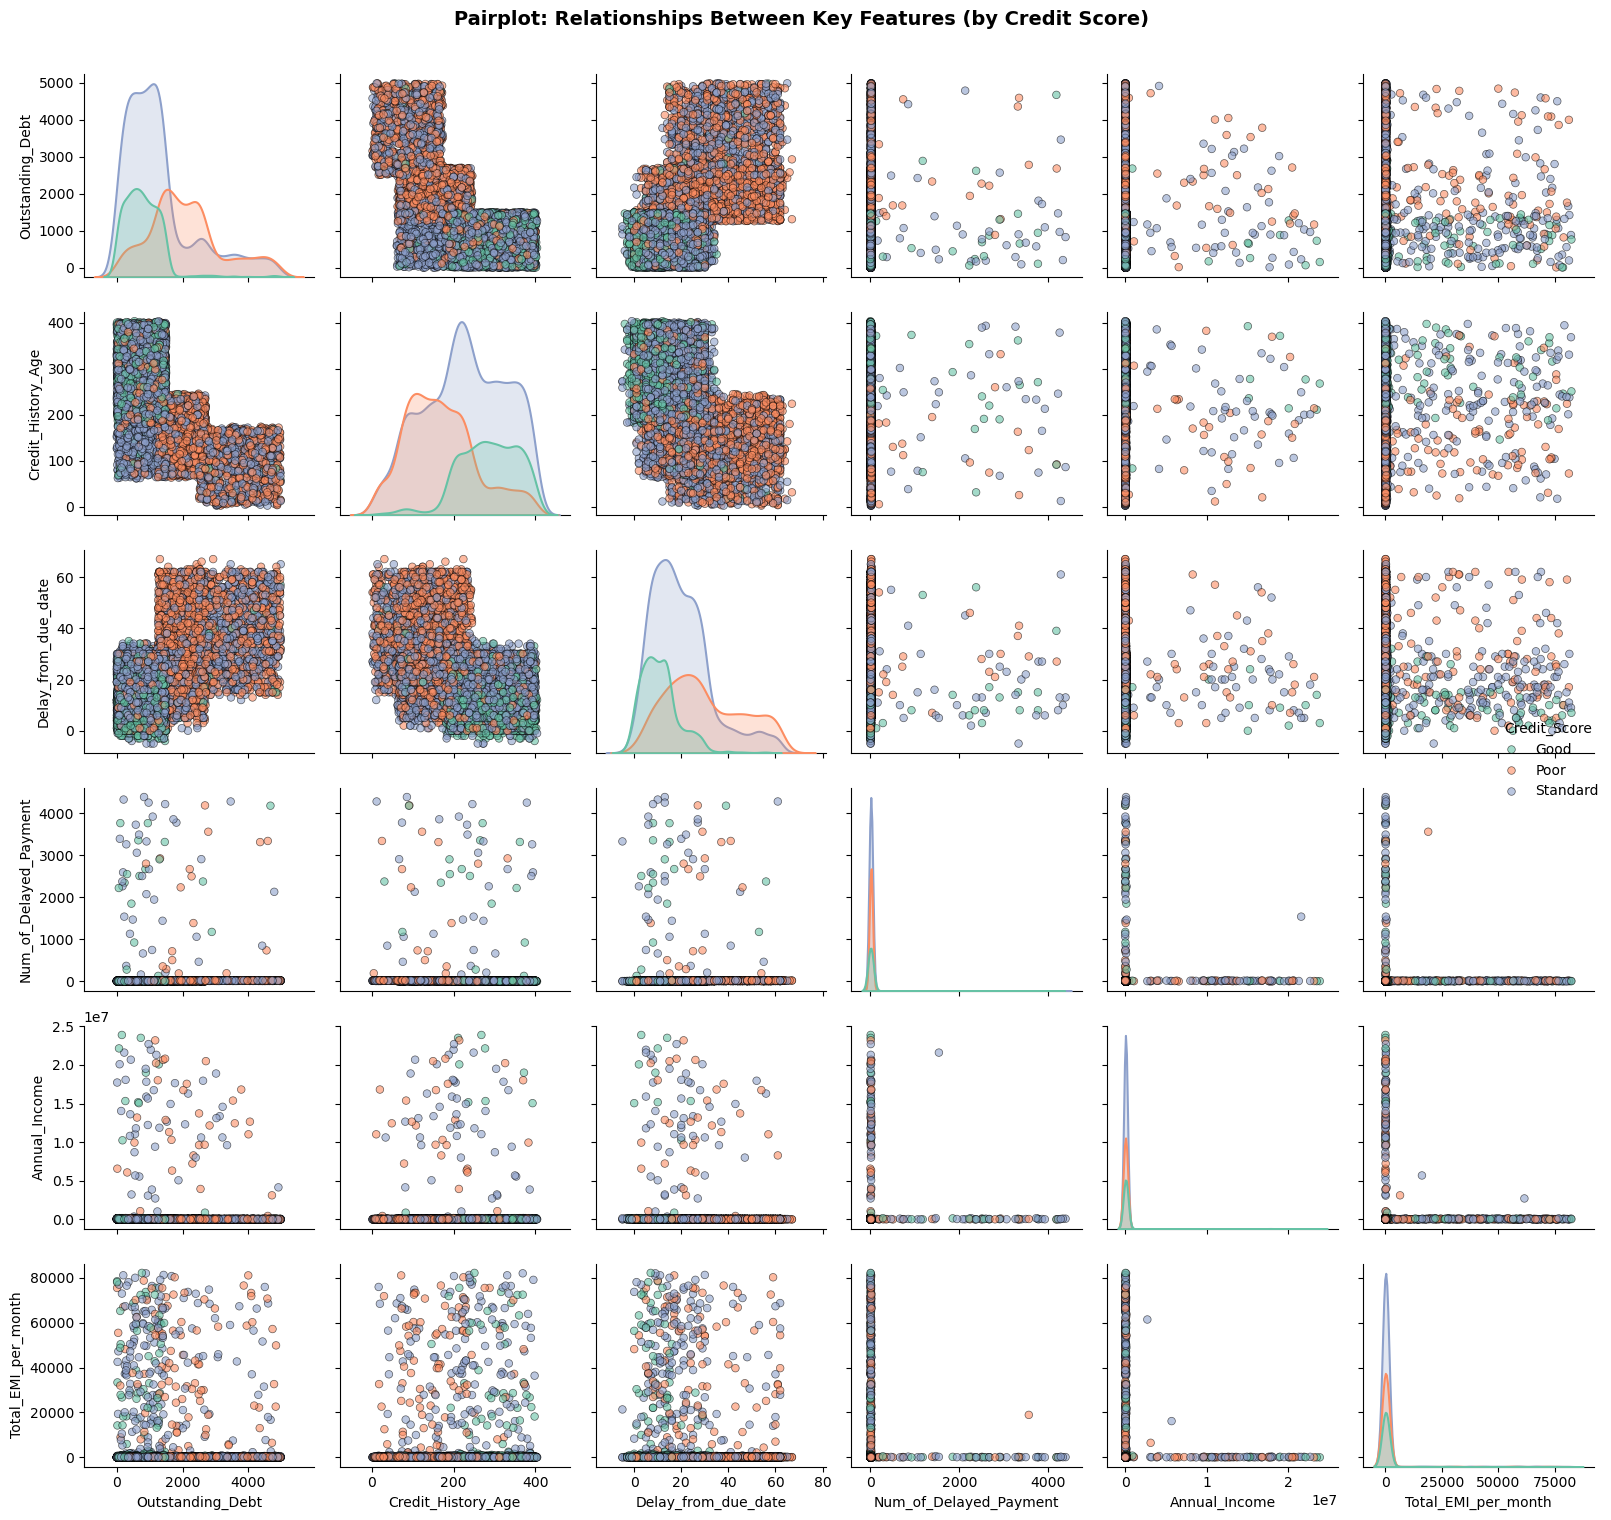


✓ Pairplot shows bivariate relationships and distributions


In [17]:
# ** NEW: PAIRPLOT for relationship analysis **
# Selecting 6 most important numerical features based on domain knowledge

print("Creating Pairplot for key features...")
print("Features selected:")
pairplot_features = [
    'Outstanding_Debt',
    'Credit_History_Age', 
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Annual_Income',
    'Total_EMI_per_month'
]

for i, feat in enumerate(pairplot_features, 1):
    print(f"  {i}. {feat}")

# Create pairplot with Credit_Score as hue
pairplot_df = df[pairplot_features + ['Credit_Score']].copy()

# Use a sample if dataset is very large (for performance)
if len(pairplot_df) > 10000:
    print(f"\nUsing sample of 10,000 rows for pairplot (original: {len(pairplot_df):,} rows)")
    pairplot_df = pairplot_df.sample(10000, random_state=42)

sns.pairplot(pairplot_df, hue='Credit_Score', palette='Set2', 
             diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k', 'linewidth': 0.5},
             diag_kws={'shade': True, 'linewidth': 1.5})

plt.suptitle('Pairplot: Relationships Between Key Features (by Credit Score)', 
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Pairplot shows bivariate relationships and distributions")

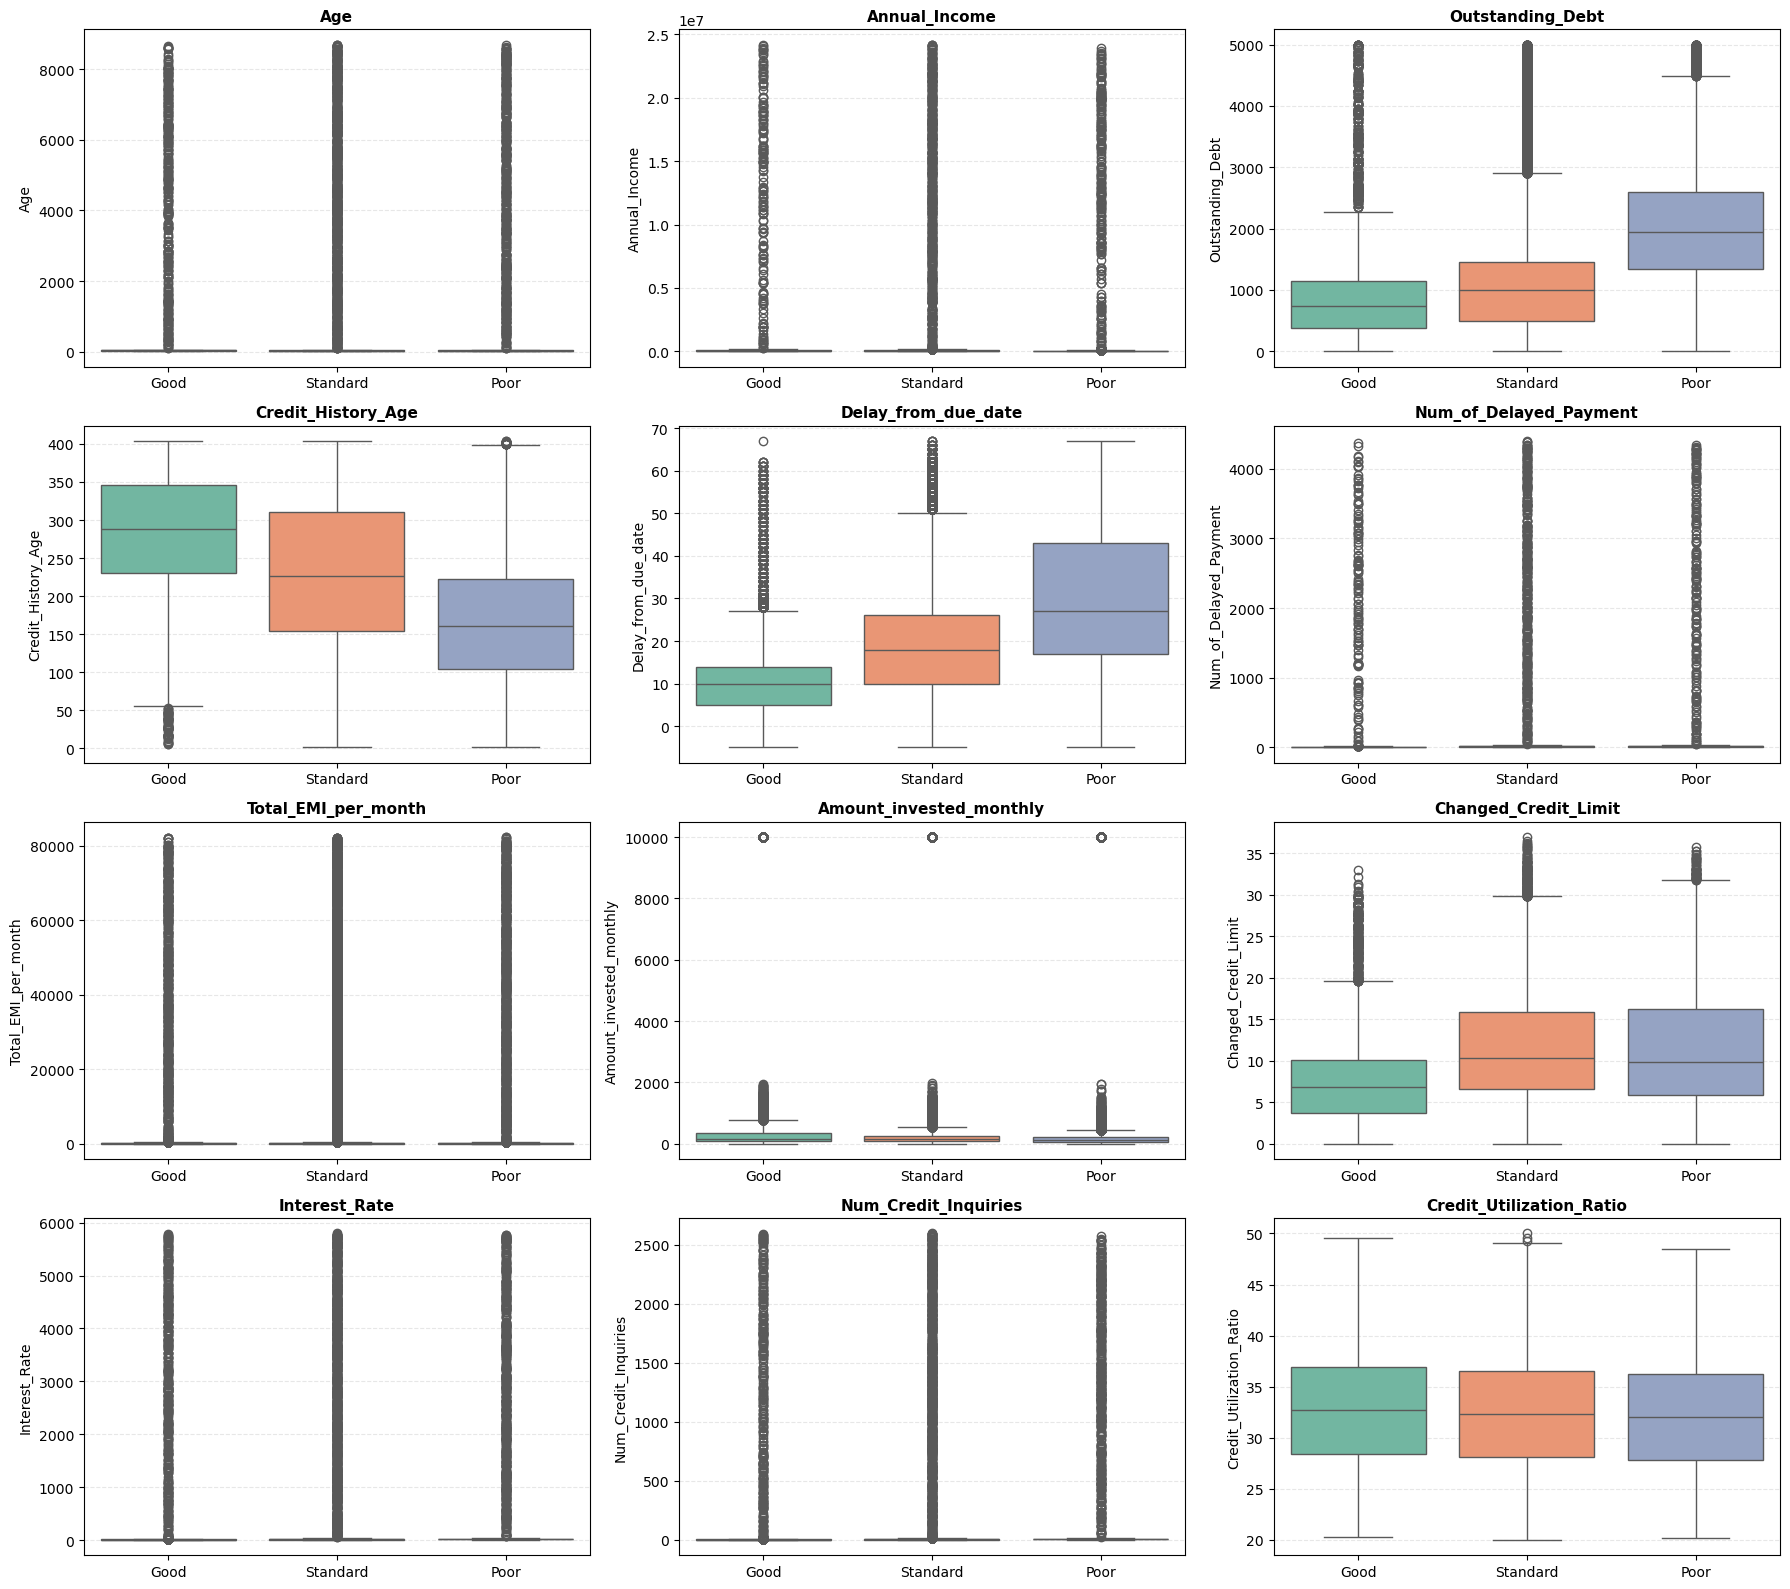


✓ Boxplots reveal feature distributions and outliers across Credit Score categories


In [18]:
# Boxplots: Feature distributions by Credit Score (sample of key features)

key_numerical = [
    'Age', 'Annual_Income', 'Outstanding_Debt', 'Credit_History_Age',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Changed_Credit_Limit', 'Interest_Rate',
    'Num_Credit_Inquiries', 'Credit_Utilization_Ratio'
]

plt.figure(figsize=(18, 16))

for ax, col in enumerate(key_numerical):
    plt.subplot(4, 3, ax + 1)
    plt.title(col, fontsize=11, fontweight='bold')
    sns.boxplot(x='Credit_Score', y=col, data=df, palette='Set2')
    plt.xlabel('')
    plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n✓ Boxplots reveal feature distributions and outliers across Credit Score categories")

In [19]:
##########################################################################
#                 5. PHASE 2 CLEANING (VALUES)                           #
##########################################################################

# Step 1: Custom missing value imputation (customer-specific approach)
print("Step 1: Imputing missing values using customer-specific strategy\n")

# Function for categorical imputation
def fill_na_cat(data, val):
    """Fill categorical NaN with customer-specific mode, then global mode"""
    nan_idx = list(data[val][data[val].isnull()].index)
    
    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].mode()
        if len(val_pred) > 0 and not pd.isna(val_pred[0]):
            data.loc[i, val] = val_pred[0]
        else:
            data.loc[i, val] = data[val].mode()[0]
    
    return list(data[val])

# Function for numerical imputation
def fill_na_num(data, val):
    """Fill numerical NaN with customer-specific median, then global median"""
    nan_idx = list(data[val][data[val].isnull()].index)
    
    for i in nan_idx:
        val_pred = data[val][data['Customer_ID'] == data.iloc[i]['Customer_ID']].median()
        
        if not pd.isna(val_pred):
            data.loc[i, val] = val_pred
        else:
            data.loc[i, val] = data[val].median()
    
    return data[val]

print("Identifying columns with missing values...")
missing_count = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': (missing_count / len(df)) * 100
})
missing_df = missing_df[missing_df['Count'] > 0].sort_values(by='Percentage', ascending=False)
print(f"\nColumns with missing values: {len(missing_df)}")
print(missing_df[['Column', 'Percentage']].to_string(index=False))

Step 1: Imputing missing values using customer-specific strategy

Identifying columns with missing values...

Columns with missing values: 14
                 Column  Percentage
             Credit_Mix      20.195
  Monthly_Inhand_Salary      15.002
           Type_of_Loan      11.408
     Credit_History_Age       9.030
 Num_of_Delayed_Payment       7.646
      Payment_Behaviour       7.600
             Occupation       7.062
Amount_invested_monthly       4.479
            Num_of_Loan       3.876
   Changed_Credit_Limit       3.677
   Num_Credit_Inquiries       1.965
        Monthly_Balance       1.200
                    Age       0.886
      Num_Bank_Accounts       0.021


In [20]:
# Impute categorical columns (excluding Type_of_Loan)
print("\nImputing categorical columns:")
missing_cat_cols = set(missing_df['Column'].tolist()).intersection(
    df.select_dtypes(include='object').columns.tolist()
)

if 'Type_of_Loan' in missing_cat_cols:
    missing_cat_cols.remove('Type_of_Loan')

for col in missing_cat_cols:
    df[col] = fill_na_cat(df, col)
    print(f"   ✓ Filled {col}")

# Impute numerical columns
print("\nImputing numerical columns:")
missing_num_cols = set(missing_df['Column'].tolist()).intersection(
    df.select_dtypes(exclude='object').columns.tolist()
)

for col in missing_num_cols:
    df[col] = fill_na_num(df, col)
    print(f"   ✓ Filled {col}")

print(f"\nRemaining NaN count: {df.isna().sum().sum()}")
print("\nType_of_Loan will be handled separately (will drop rows with NaN in this column)")


Imputing categorical columns:
   ✓ Filled Credit_Mix
   ✓ Filled Occupation
   ✓ Filled Payment_Behaviour

Imputing numerical columns:
   ✓ Filled Monthly_Balance
   ✓ Filled Age
   ✓ Filled Monthly_Inhand_Salary
   ✓ Filled Amount_invested_monthly
   ✓ Filled Num_Bank_Accounts
   ✓ Filled Num_of_Loan
   ✓ Filled Credit_History_Age
   ✓ Filled Num_of_Delayed_Payment
   ✓ Filled Num_Credit_Inquiries
   ✓ Filled Changed_Credit_Limit

Remaining NaN count: 11408

Type_of_Loan will be handled separately (will drop rows with NaN in this column)



Step 2: Processing Type_of_Loan column

Unique loan types found: 9
   - Auto Loan: 37,992
   - Credit-Builder Loan: 40,440
   - Personal Loan: 38,888
   - Home Equity Loan: 39,104
   - Not Specified: 39,616
   - Mortgage Loan: 38,936
   - Student Loan: 38,968
   - Debt Consolidation Loan: 38,776
   - Payday Loan: 40,568


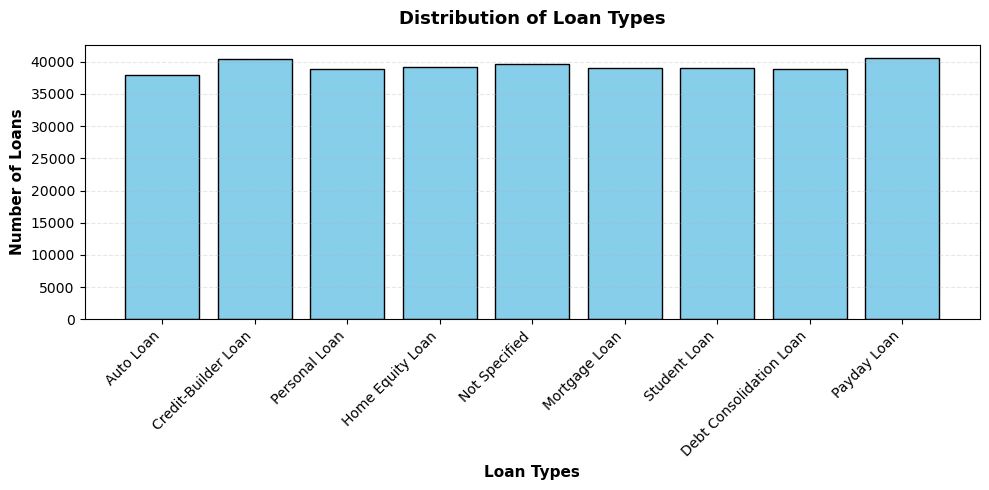


Missing Type_of_Loan: 11.41%
Decision: Dropping rows with missing Type_of_Loan
   Shape before: (100000, 26)
   Shape after:  (88592, 26)
   ✓ Dropped 11,408 rows


In [21]:
# Step 2: Handle Type_of_Loan (multi-value column → binary columns)
print("\nStep 2: Processing Type_of_Loan column")

# Extract unique loan types
loan_types = {}
for idx, row in df.iterrows():
    vals = row['Type_of_Loan']
    if pd.isnull(vals):
        continue
    
    vals = vals.replace('and', '').split(', ')
    for val in vals:
        val = val.strip()
        loan_types[val] = loan_types.get(val, 0) + 1

print(f"\nUnique loan types found: {len(loan_types)}")
for k, v in loan_types.items():
    print(f"   - {k}: {v:,}")

# Visualize loan distribution
plt.figure(figsize=(10, 5))
plt.bar(loan_types.keys(), loan_types.values(), color='skyblue', edgecolor='black')
plt.xlabel('Loan Types', fontsize=11, fontweight='bold')
plt.ylabel('Number of Loans', fontsize=11, fontweight='bold')
plt.title('Distribution of Loan Types', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Check percentage of missing Type_of_Loan
missing_pct = df['Type_of_Loan'].isna().sum() / len(df) * 100
print(f"\nMissing Type_of_Loan: {missing_pct:.2f}%")
print("Decision: Dropping rows with missing Type_of_Loan")

# Drop rows with NaN in Type_of_Loan
before_shape = df.shape
df.dropna(inplace=True)
after_shape = df.shape
print(f"   Shape before: {before_shape}")
print(f"   Shape after:  {after_shape}")
print(f"   ✓ Dropped {before_shape[0] - after_shape[0]:,} rows")

In [22]:
# Create binary columns for each loan type
print("\nCreating binary columns for each loan type...")

col_map = {True: 1, False: 0}

for loan_type in list(loan_types.keys()):
    df[loan_type] = df['Type_of_Loan'].str.contains(loan_type).map(col_map)
    print(f"   ✓ Created column: {loan_type}")

# Drop original Type_of_Loan and 'Not Specified' column
df.drop(['Type_of_Loan', 'Not Specified'], axis=1, inplace=True)
print("\n   ✓ Dropped 'Type_of_Loan' and 'Not Specified' columns")

print(f"\nCurrent shape: {df.shape}")


Creating binary columns for each loan type...
   ✓ Created column: Auto Loan
   ✓ Created column: Credit-Builder Loan
   ✓ Created column: Personal Loan
   ✓ Created column: Home Equity Loan
   ✓ Created column: Not Specified
   ✓ Created column: Mortgage Loan
   ✓ Created column: Student Loan
   ✓ Created column: Debt Consolidation Loan
   ✓ Created column: Payday Loan

   ✓ Dropped 'Type_of_Loan' and 'Not Specified' columns

Current shape: (88592, 33)



Step 3: Detecting and treating outliers using IQR method

Columns with >1% outliers:
                 Column  Has_Outliers  Percentage
      Num_Bank_Accounts          True        1.31
   Num_Credit_Inquiries          True        1.64
                    Age          True        1.88
          Interest_Rate          True        2.05
        Num_Credit_Card          True        2.24
  Monthly_Inhand_Salary          True        2.31
          Annual_Income          True        2.94
    Delay_from_due_date          True        3.27
       Outstanding_Debt          True        3.44
    Total_EMI_per_month          True        6.55
        Monthly_Balance          True        7.76
Amount_invested_monthly          True       10.49


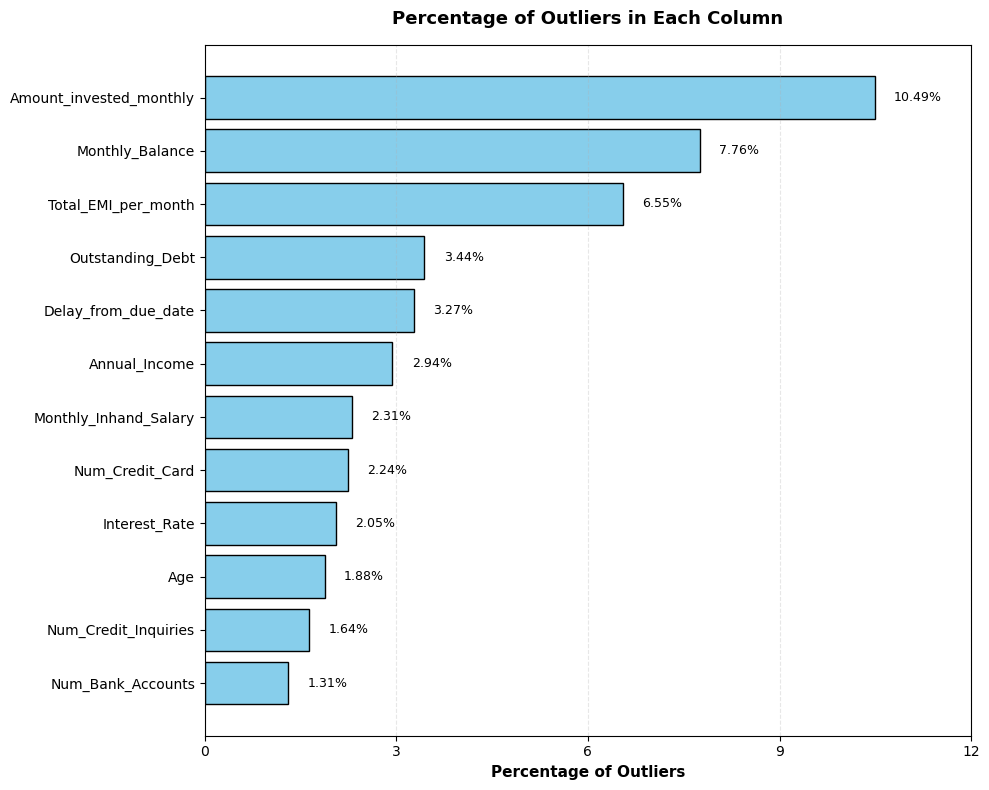

In [23]:
# Step 3: Outlier detection and treatment
print("\nStep 3: Detecting and treating outliers using IQR method\n")

def outlier_thresholds(data, col_name):
    """Calculate outlier thresholds using IQR method"""
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    return lower_limit, upper_limit

def check_outlier(data, col_name):
    """Check if column has outliers and calculate percentage"""
    lower_limit, upper_limit = outlier_thresholds(data, col_name)
    
    outliers = data[(data[col_name] > upper_limit) | (data[col_name] < lower_limit)]
    percentage_outliers = (len(outliers) / len(data)) * 100
    
    return outliers.any(axis=None), round(percentage_outliers, 2)

# Get numerical columns (excluding loan binary columns and Credit_Score_Encoded)
num_cols_for_outliers = df.select_dtypes(include=['int64', 'float64']).columns[1:-9].tolist()

# Check outliers
outlier_rows = []
for col in num_cols_for_outliers:
    has_outliers, percentage = check_outlier(df, col)
    outlier_rows.append({
        'Column': col,
        'Has_Outliers': has_outliers,
        'Percentage': percentage
    })

outlier_results = pd.DataFrame(outlier_rows)
outlier_results = outlier_results[outlier_results['Has_Outliers']]
outlier_results = outlier_results[outlier_results['Percentage'] > 1]
outlier_results = outlier_results.sort_values(by='Percentage')

print("Columns with >1% outliers:")
print(outlier_results.to_string(index=False))

# Visualize outlier percentages
plt.figure(figsize=(10, 8))
bars = plt.barh(outlier_results['Column'], outlier_results['Percentage'], 
                color='skyblue', edgecolor='black')
plt.xlabel('Percentage of Outliers', fontsize=11, fontweight='bold')
plt.title('Percentage of Outliers in Each Column', fontsize=13, fontweight='bold', pad=15)
plt.xticks(np.arange(0, outlier_results['Percentage'].max() + 3, 3))
plt.grid(axis='x', alpha=0.3, linestyle='--')

for bar, label in zip(bars, outlier_results['Percentage']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, 
             f'{label:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# Apply outlier treatment: capping/winsorization
print("\nApplying outlier treatment (capping to IQR limits)...")

def replace_with_thresholds(data, col):
    """Replace outliers with threshold limits"""
    lower_limit, upper_limit = outlier_thresholds(data, col)
    
    data.loc[(data[col] < lower_limit), col] = lower_limit
    data.loc[(data[col] > upper_limit), col] = upper_limit

for col in num_cols_for_outliers:
    replace_with_thresholds(df, col)

print(f"   ✓ Outliers capped for {len(num_cols_for_outliers)} columns")

# Verify outlier treatment
print("\nVerifying outlier treatment...")
post_treatment_outliers = []
for col in outlier_results['Column']:
    has_outliers, percentage = check_outlier(df, col)
    post_treatment_outliers.append({
        'Column': col,
        'Outliers_Remaining': percentage
    })

post_df = pd.DataFrame(post_treatment_outliers)
print(post_df.to_string(index=False))
print("\n✓ Outlier treatment complete!")


Applying outlier treatment (capping to IQR limits)...
   ✓ Outliers capped for 17 columns

Verifying outlier treatment...
                 Column  Outliers_Remaining
      Num_Bank_Accounts                 0.0
   Num_Credit_Inquiries                 0.0
                    Age                 0.0
          Interest_Rate                 0.0
        Num_Credit_Card                 0.0
  Monthly_Inhand_Salary                 0.0
          Annual_Income                 0.0
    Delay_from_due_date                 0.0
       Outstanding_Debt                 0.0
    Total_EMI_per_month                 0.0
        Monthly_Balance                 0.0
Amount_invested_monthly                 0.0

✓ Outlier treatment complete!


In [25]:
# Step 4: Statistical tests for feature selection

# Move Credit_Score to end for convenience
print("\nStep 4: Feature Selection using Statistical Tests\n")

y = df['Credit_Score']
df = df.drop('Credit_Score', axis=1)
df['Credit_Score'] = y

# Remove temporary encoding column
if 'Credit_Score_Encoded' in df.columns:
    df = df.drop('Credit_Score_Encoded', axis=1)

print(f"Current shape: {df.shape}")
print(f"Target column moved to end: Credit_Score")


Step 4: Feature Selection using Statistical Tests

Current shape: (88592, 32)
Target column moved to end: Credit_Score


In [26]:
# Chi-Square test for categorical features
print("Running Chi-Square tests on categorical features...\n")

def chi_square_test(data, col1, col2='Credit_Score'):
    """Perform chi-square test of independence"""
    occ = data[[col1, col2]]
    table = pd.crosstab(index=occ[col1], columns=occ[col2])
    
    t, p, sd, expected = stats.chi2_contingency(table)
    
    return t, p

# Test categorical features
q_test_cols = ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
test_df = df[q_test_cols + ['Credit_Score']]

cols, values, p_values = [], [], []

for col in q_test_cols:
    cols.append(col)
    t, p = chi_square_test(test_df, col)
    values.append(round(t, 2))
    p_values.append(round(p, 4))

chi_df = pd.DataFrame({
    'Variable': cols,
    'Chi_Square_Value': values,
    'P_value': p_values
})

chi_df = chi_df.sort_values(by='Chi_Square_Value', ascending=False)

print("Chi-Square Test Results:")
print(chi_df.to_string(index=False))

# Visualize
styled_chi = chi_df.style.bar('Chi_Square_Value', color='#5588cc').background_gradient('Blues', subset='Chi_Square_Value')
styled_chi

print("\n⚠️  Dropping features with lowest chi-square values: Month, Occupation")
df.drop(['Month', 'Occupation'], axis=1, inplace=True)
print(f"   ✓ New shape: {df.shape}")

Running Chi-Square tests on categorical features...

Chi-Square Test Results:
             Variable  Chi_Square_Value  P_value
           Credit_Mix          36275.53      0.0
Payment_of_Min_Amount          15380.35      0.0
    Payment_Behaviour           1442.73      0.0
           Occupation            175.22      0.0
                Month            171.88      0.0

⚠️  Dropping features with lowest chi-square values: Month, Occupation
   ✓ New shape: (88592, 30)


In [27]:
# ANOVA test for numerical features
print("\nRunning ANOVA tests on numerical features...\n")

def anova_test(data, col1, col2='Credit_Score'):
    """Perform Welch's ANOVA test"""
    df_test = data[[col1, col2]]
    df_melted = pd.melt(df_test, id_vars=col2, var_name=col1, value_name='value')
    test = pg.welch_anova(data=df_melted, dv='value', between=col2)
    
    return test

# Get numerical columns (excluding loan binary columns)
df_numeric = df.select_dtypes(include=['int', 'float'])

# Remove loan columns for ANOVA test
loan_cols = [
    'Auto Loan', 'Credit-Builder Loan', 'Personal Loan',
    'Home Equity Loan', 'Mortgage Loan', 'Student Loan',
    'Debt Consolidation Loan', 'Payday Loan'
]

anova_test_cols = [col for col in df_numeric.columns if col not in loan_cols and col != 'Credit_Score']

cols, values, p_values = [], [], []

for col in anova_test_cols:
    cols.append(col)
    test = anova_test(df, col)
    values.append(round(float(test['F'].values), 2))
    p_values.append(round(float(test['p-unc'].values), 6))

anova_df = pd.DataFrame({
    'Variable': cols,
    'F_Value': values,
    'P_value': p_values
})

anova_df = anova_df.sort_values(by='F_Value', ascending=False)

print("ANOVA Test Results (Top 15):")
print(anova_df.head(15).to_string(index=False))

print("\n...")
print("\nANOVA Test Results (Bottom 5):")
print(anova_df.tail(5).to_string(index=False))

# Visualize
styled_anova = anova_df.style.bar('F_Value', color='#5588cc').background_gradient('Blues', subset='F_Value')
styled_anova

print("\n⚠️  Dropping features with lowest F-values (bottom 3):")
cols_to_drop = anova_df['Variable'][-3:].tolist()
for col in cols_to_drop:
    print(f"   - {col}")

df.drop(cols_to_drop, axis=1, inplace=True)
print(f"\n   ✓ New shape: {df.shape}")


Running ANOVA tests on numerical features...

ANOVA Test Results (Top 15):
               Variable  F_Value  P_value
    Delay_from_due_date 13219.88      0.0
          Interest_Rate 12444.16      0.0
       Outstanding_Debt 12108.61      0.0
     Credit_History_Age 11195.13      0.0
   Num_Credit_Inquiries 10447.87      0.0
      Num_Bank_Accounts  7536.13      0.0
 Num_of_Delayed_Payment  7352.95      0.0
            Num_of_Loan  6957.47      0.0
        Num_Credit_Card  6943.56      0.0
   Changed_Credit_Limit  3629.97      0.0
        Monthly_Balance  2188.98      0.0
  Monthly_Inhand_Salary  2147.91      0.0
          Annual_Income  2043.24      0.0
                    Age   948.11      0.0
Amount_invested_monthly   677.22      0.0

...

ANOVA Test Results (Bottom 5):
                Variable  F_Value  P_value
                     Age   948.11 0.000000
 Amount_invested_monthly   677.22 0.000000
Credit_Utilization_Ratio    73.75 0.000000
     Total_EMI_per_month    55.64 0.000000



Step 5: Final Missing Values Check



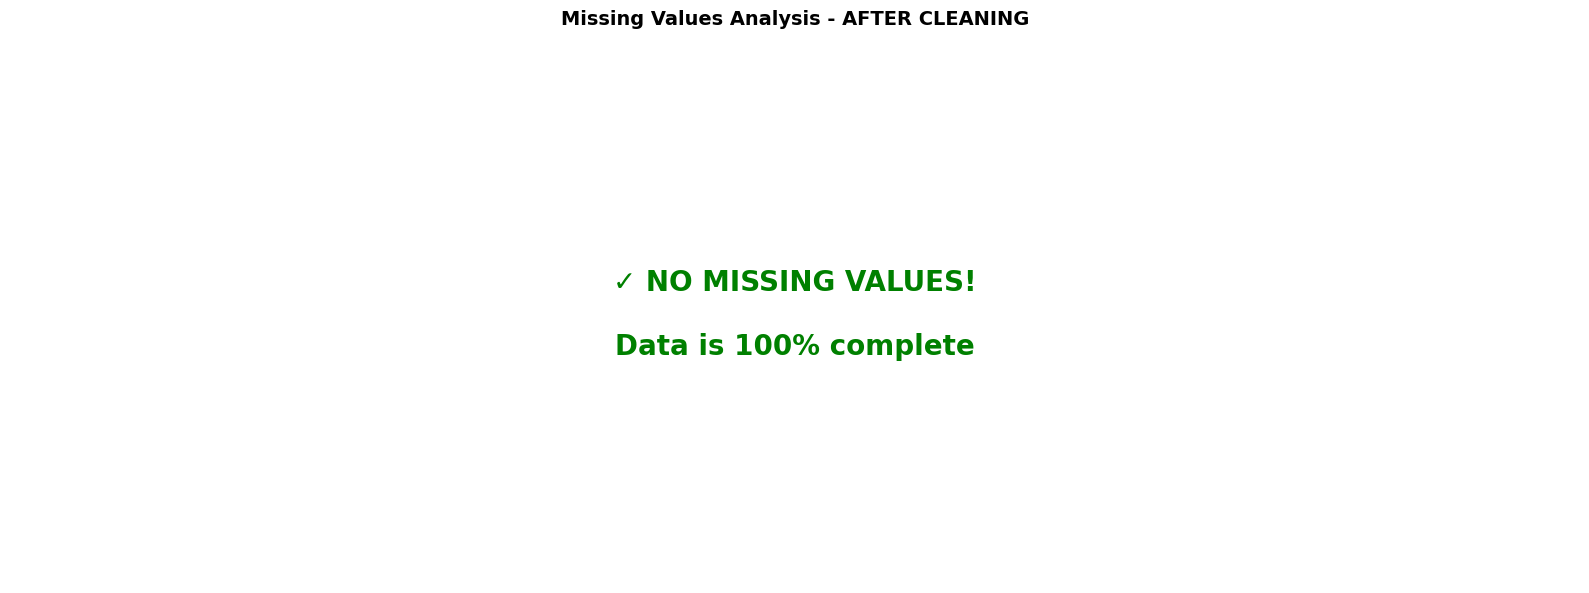

✓ SUCCESS: No missing values in the dataset!
   Total rows: 88,592
   Total columns: 27
   Total cells: 2,391,984

PHASE 2 CLEANING COMPLETE - Data is ready for preprocessing!


In [28]:
# Step 5: FINAL MISSING VALUES CHECK (should be 0!)
print("\nStep 5: Final Missing Values Check\n")
print("="*70)

# Re-visualize missing values with the styled horizontal bar chart
fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))

# Calculate missing values
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Filter columns with missing values
missing_df_final = pd.DataFrame({
    'Column': df.columns,
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_df_final = missing_df_final[missing_df_final['Count'] > 0].sort_values(by='Percentage', ascending=False)

if len(missing_df_final) > 0:
    # Horizontal bar chart with gradient colors
    colors_gradient = plt.cm.RdYlGn_r(missing_df_final['Percentage'] / missing_df_final['Percentage'].max())
    bars = ax1.barh(missing_df_final['Column'], missing_df_final['Percentage'], color=colors_gradient, 
                    edgecolor='black', linewidth=1)
    
    ax1.set_xlabel('Missing Percentage (%)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Column', fontsize=11, fontweight='bold')
    ax1.set_title('Missing Values by Percentage (AFTER CLEANING)', fontsize=13, fontweight='bold', pad=15)
    ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
    
    # Add percentage labels on bars
    for i, (bar, pct, count) in enumerate(zip(bars, missing_df_final['Percentage'], missing_df_final['Count'])):
        width = bar.get_width()
        ax1.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}% ({int(count):,})',
                 ha='left', va='center', fontsize=9, fontweight='bold')
    
    # Add summary statistics
    total_missing = missing_count.sum()
    total_cells = df.shape[0] * df.shape[1]
    overall_pct = (total_missing / total_cells) * 100
    
    fig.suptitle(f'Missing Values Analysis | Total Missing: {int(total_missing):,} ({overall_pct:.2f}% of all data)', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    print(f"⚠️  WARNING: {len(missing_df_final)} columns still have missing values!")
else:
    # No missing values - show success message
    ax1.text(0.5, 0.5, '✓ NO MISSING VALUES!\n\nData is 100% complete', 
             ha='center', va='center', fontsize=20, fontweight='bold', 
             color='green', transform=ax1.transAxes)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.axis('off')
    
    fig.suptitle('Missing Values Analysis - AFTER CLEANING', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ SUCCESS: No missing values in the dataset!")
    print(f"   Total rows: {df.shape[0]:,}")
    print(f"   Total columns: {df.shape[1]}")
    print(f"   Total cells: {df.shape[0] * df.shape[1]:,}")

print("\n" + "="*70)
print("PHASE 2 CLEANING COMPLETE - Data is ready for preprocessing!")
print("="*70)

In [29]:
##########################################################################
#                      6. PREPROCESSING                                  #
##########################################################################

print("Preparing features for modeling...\n")

# Step 1: Separate features and target
print("Step 1: Separating features and target")

features = df.drop('Credit_Score', axis=1)
label = df['Credit_Score']

print(f"   Features shape: {features.shape}")
print(f"   Target shape: {label.shape}")
print(f"   Target distribution:\n{label.value_counts()}")

Preparing features for modeling...

Step 1: Separating features and target
   Features shape: (88592, 26)
   Target shape: (88592,)
   Target distribution:
Credit_Score
Standard    46546
Poor        27662
Good        14384
Name: count, dtype: int64


In [30]:
# Step 2: Encode Target Variable
print("\nStep 2: Encoding target variable (Credit_Score)")

label_map = {
    'Poor': 0,
    'Standard': 1,
    'Good': 2
}

label = label.map(label_map)

print("   Encoding scheme:")
for k, v in label_map.items():
    print(f"      {k} → {v}")

print(f"\n   Encoded target distribution:")
print(label.value_counts().sort_index())
print(f"   ✓ Target encoded successfully")


Step 2: Encoding target variable (Credit_Score)
   Encoding scheme:
      Poor → 0
      Standard → 1
      Good → 2

   Encoded target distribution:
Credit_Score
0    27662
1    46546
2    14384
Name: count, dtype: int64
   ✓ Target encoded successfully


In [31]:
# Step 3: Encode Categorical Features
print("\nStep 3: Encoding categorical features\n")

# Identify categorical columns
cat_col = features.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns found: {cat_col}")

# Display value counts for each
for col in cat_col:
    print(f"\n{col} value counts:")
    print(features[col].value_counts())
    print()


Step 3: Encoding categorical features

Categorical columns found: ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

Credit_Mix value counts:
Credit_Mix
Standard    40736
Good        24088
Bad         23768
Name: count, dtype: int64


Payment_of_Min_Amount value counts:
Payment_of_Min_Amount
Yes    49515
No     39077
Name: count, dtype: int64


Payment_Behaviour value counts:
Payment_Behaviour
Low_spent_Small_value_payments      25227
High_spent_Medium_value_payments    16993
High_spent_Large_value_payments     13199
Low_spent_Medium_value_payments     12887
High_spent_Small_value_payments     10613
Low_spent_Large_value_payments       9673
Name: count, dtype: int64



In [32]:
# Ordinal encoding for Credit_Mix
print("Encoding Credit_Mix (ordinal)...")
cred_mix = {
    'Bad': 0,
    'Standard': 1,
    'Good': 2
}
features['Credit_Mix'] = features['Credit_Mix'].map(cred_mix)
print(f"   ✓ Credit_Mix: Bad→0, Standard→1, Good→2")

# Binary encoding for Payment_of_Min_Amount
print("\nEncoding Payment_of_Min_Amount (binary)...")
min_pay = {
    'No': 0,
    'Yes': 1,
}
features['Payment_of_Min_Amount'] = features['Payment_of_Min_Amount'].map(min_pay)
print(f"   ✓ Payment_of_Min_Amount: No→0, Yes→1")

# One-hot encoding for Payment_Behaviour
print("\nEncoding Payment_Behaviour (one-hot with drop_first=True)...")
print(f"   Unique values: {features['Payment_Behaviour'].nunique()}")

features = pd.get_dummies(features, columns=['Payment_Behaviour'], drop_first=True, dtype=int)
print(f"   ✓ Payment_Behaviour one-hot encoded")
print(f"\n   New features shape: {features.shape}")

# Display new columns created
payment_behaviour_cols = [col for col in features.columns if 'Payment_Behaviour' in col]
print(f"   Created {len(payment_behaviour_cols)} new columns:")
for col in payment_behaviour_cols[:5]:
    print(f"      - {col}")
if len(payment_behaviour_cols) > 5:
    print(f"      ... and {len(payment_behaviour_cols) - 5} more")

Encoding Credit_Mix (ordinal)...
   ✓ Credit_Mix: Bad→0, Standard→1, Good→2

Encoding Payment_of_Min_Amount (binary)...
   ✓ Payment_of_Min_Amount: No→0, Yes→1

Encoding Payment_Behaviour (one-hot with drop_first=True)...
   Unique values: 6
   ✓ Payment_Behaviour one-hot encoded

   New features shape: (88592, 30)
   Created 5 new columns:
      - Payment_Behaviour_High_spent_Medium_value_payments
      - Payment_Behaviour_High_spent_Small_value_payments
      - Payment_Behaviour_Low_spent_Large_value_payments
      - Payment_Behaviour_Low_spent_Medium_value_payments
      - Payment_Behaviour_Low_spent_Small_value_payments


In [33]:
# Step 4: Optimize data types (convert floats to ints where appropriate)
print("\nStep 4: Optimizing data types\n")

# Find float columns that only contain integer values
float_cols_with_integers = features.select_dtypes(include='float').apply(
    lambda col: col.apply(lambda x: x.is_integer()).all()
)
float_cols_to_convert = float_cols_with_integers[float_cols_with_integers].index.tolist()

print(f"Float columns containing only integers: {len(float_cols_to_convert)}")
if len(float_cols_to_convert) > 0:
    print(f"   Converting: {float_cols_to_convert[:5]}")
    if len(float_cols_to_convert) > 5:
        print(f"   ... and {len(float_cols_to_convert) - 5} more")
    
    features[float_cols_to_convert] = features[float_cols_to_convert].astype(int)
    print(f"   ✓ Converted {len(float_cols_to_convert)} columns to int")

# Specific conversions for Age and Credit_History_Age
age_cols = ['Age', 'Credit_History_Age']
for col in age_cols:
    if col in features.columns and features[col].dtype == 'float':
        features[col] = features[col].astype(int)
        print(f"   ✓ Converted {col} to int")

print(f"\nFinal features info:")
features.info()


Step 4: Optimizing data types

Float columns containing only integers: 2
   Converting: ['Num_Bank_Accounts', 'Num_of_Loan']
   ✓ Converted 2 columns to int
   ✓ Converted Age to int
   ✓ Converted Credit_History_Age to int

Final features info:
<class 'pandas.core.frame.DataFrame'>
Index: 88592 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 88592 non-null  int64  
 1   Annual_Income                                       88592 non-null  float64
 2   Monthly_Inhand_Salary                               88592 non-null  float64
 3   Num_Bank_Accounts                                   88592 non-null  int64  
 4   Num_Credit_Card                                     88592 non-null  float64
 5   Interest_Rate                                       88592 non-null  int64  
 

In [34]:
# Final Summary
print("\n" + "="*70)
print("                    PREPROCESSING COMPLETE!                        ")
print("="*70)

print("\n📊 FINAL DATASET SUMMARY:")
print(f"   • Total samples: {features.shape[0]:,}")
print(f"   • Total features: {features.shape[1]}")
print(f"   • Target classes: {label.nunique()} (Poor: 0, Standard: 1, Good: 2)")
print(f"   • Missing values: {features.isnull().sum().sum()} (0.00%)")
print(f"   • Data types: {features.dtypes.value_counts().to_dict()}")

print("\n📈 TARGET DISTRIBUTION:")
target_dist = label.value_counts().sort_index()
for idx, count in target_dist.items():
    pct = (count / len(label)) * 100
    class_name = ['Poor', 'Standard', 'Good'][idx]
    print(f"   • Class {idx} ({class_name}): {count:,} samples ({pct:.2f}%)")

print("\n🎯 READY FOR:")
print("   ✓ Train/Test split")
print("   ✓ Feature scaling (RobustScaler recommended)")
print("   ✓ Model training and evaluation")

print("\n" + "="*70)
print("Variables ready for modeling:")
print("   - features: DataFrame with shape", features.shape)
print("   - label: Series with shape", label.shape)
print("="*70)


                    PREPROCESSING COMPLETE!                        

📊 FINAL DATASET SUMMARY:
   • Total samples: 88,592
   • Total features: 30
   • Target classes: 3 (Poor: 0, Standard: 1, Good: 2)
   • Missing values: 0 (0.00%)
   • Data types: {dtype('int64'): 20, dtype('float64'): 10}

📈 TARGET DISTRIBUTION:
   • Class 0 (Poor): 27,662 samples (31.22%)
   • Class 1 (Standard): 46,546 samples (52.54%)
   • Class 2 (Good): 14,384 samples (16.24%)

🎯 READY FOR:
   ✓ Train/Test split
   ✓ Feature scaling (RobustScaler recommended)
   ✓ Model training and evaluation

Variables ready for modeling:
   - features: DataFrame with shape (88592, 30)
   - label: Series with shape (88592,)
